# ML de demanda, features de precio y optimización


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS

from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from skforecast.model_selection import bayesian_search_forecaster

import shap


In [2]:
pepsi = pd.read_parquet('../data/processed/pepsi_2l_features.parquet')

print(pepsi.shape)
print(pepsi.columns.tolist())

(26663, 22)
['STORE', 'UPC', 'WEEK', 'MOVE', 'QTY', 'PRICE', 'SALE', 'PROFIT', 'DESCRIP', 'SIZE', 'COM_CODE', 'start', 'end', 'special', 'UNIT_PRICE', 'ln_q', 'ln_p', 'PROMO', 'FESTIVO', 'PRECIO_REF', 'DESCUENTO', 'PRECIO_REF_COCA']


In [3]:
# agregamos serie
pepsi_agregado = pepsi.groupby('start').agg(
    UNIDADES=('MOVE', 'mean'), # media por tienda
    PRECIO_REF=('PRECIO_REF', 'mean'), # precio regular medio por semana
    DESCUENTO=('DESCUENTO','mean'), # descuento medio por semana
    PRECIO_REF_COCA=('PRECIO_REF_COCA', 'mean'),
    FESTIVO=('FESTIVO', 'max'), # max porque el festivo es una característica de la semana. O es festivo o no lo es.
    N_TIENDAS=('STORE', 'nunique')
).reset_index().sort_values('start')

display(pepsi_agregado.head())

# Nos aseguramos que todo está correcto
print(f'Forma: {pepsi_agregado.shape}')
print(pepsi_agregado['FESTIVO'].value_counts())

,start,UNIDADES,PRECIO_REF,DESCUENTO,PRECIO_REF_COCA,FESTIVO,N_TIENDAS
0,1991-01-03,188.088608,1.573418,0.000000,1.573924,0,79
1,1991-01-10,403.087500,1.572788,0.193035,1.572750,0,80
2,1991-01-17,156.365854,1.575610,0.000306,1.576488,0,82
3,1991-01-24,158.629630,1.575185,0.001100,1.575309,0,81
4,1991-01-31,293.365854,1.575366,0.194921,1.576585,0,82


Forma: (322, 7)
FESTIVO
0    267
1     55
Name: count, dtype: int64


Para el modelo de predicción se agrega el panel a una única serie semanal. Cada variable seagrega según su naturaleza: las unidades y las variables de precio (precio regular, descuento, precio de Coca) se promedian entre tiendas, mientras que el festivo se colapsa con el máximo, al ser una característica de la semana y no de la tienda. Al promediar el precio entre tiendas se pierde la variación entre establecimientos que se explotó en la estimación de la elasticidad; aquí no es un problema, porque el objetivo es predecir la demanda agregada, no estimar el efecto causal del precio. Es la diferencia entre inferencia (que requería el panel) y predicción (que trabaja sobre la serie agregada).

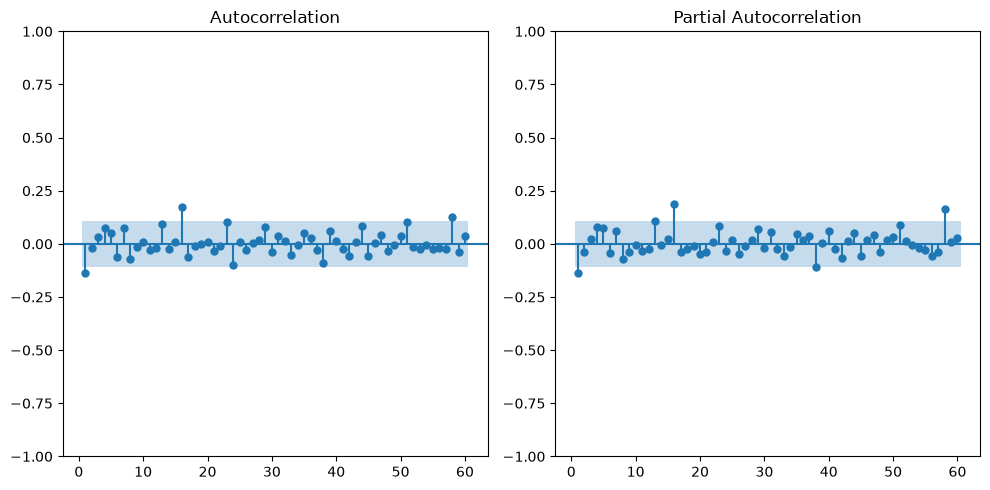

In [4]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

plot_acf(pepsi_agregado['UNIDADES'], lags=60, ax=ax[0], zero=False, bartlett_confint=False)
plot_pacf(pepsi_agregado['UNIDADES'], lags=60, ax=ax[1], zero=False)

plt.tight_layout()
plt.show()

El `ACF` y `PACF` de la demanda son prácticamente planos, casi todas las autocorrelaciones caen dentro de la banda de significancia. Esto nos lleva a que la demanda de Pepsi, apenas es explicada por su propio pasado, lo que confirma el principal elemento de la serie no es la inercia temporal, sino el precio y la promoción, tal cómo se ha podido comprobar en el cálculo de la elasticidad y descomposición `STL`. En consecuencia, los lags de demanda se incluirán como predictores menores y se anticipa que los modelos basados solo en valores pasados de la serie (los que se emplearán como benchmark) tendrán un rendimiento pobre frente a modelos que incorporen el precio.

## Feature Engineering


In [5]:
pepsi_agregado = pepsi_agregado.sort_values('start').reset_index(drop=True)

# Features calendario
pepsi_agregado['WEEK_YEAR'] = pepsi_agregado['start'].dt.isocalendar().week.astype(int)
pepsi_agregado['MES'] = pepsi_agregado['start'].dt.month



## Benchmark

Antes de entrenar el modelo de ML se establece un conjunto de modelos de referencia que solo usan el pasado de la demanda, sin información de precio. Sirven como referencia: si el modelo con precio no los supera, no estaría aportando valor. 

- **Naive:** predice que la demanda será igual a la de la última semana observada.
- **Seasonal Naive:** predice que será igual a la de la misma semana del año anterior.
- **AutoETS:** suavizado exponencial con la configuración (tendencia, estacionalidad) elegida automáticamente por criterios estadísticos.

Todos se evalúan con backtesting de origen deslizante (13 ventanas, horizonte de 4 semanas) sobre el conjunto de entrenamiento, reservando el último año como test final intacto. La métrica principal es el MAE, acompañada del RMSE.

In [6]:
FIN_TRAIN = '1996-05-01'

train = pepsi_agregado[pepsi_agregado['start'] <= FIN_TRAIN].copy()
test = pepsi_agregado[pepsi_agregado['start'] > FIN_TRAIN].copy()

print(f'Inicio Train: {train["start"].min()}; Fin Train: {train["start"].max()}')
print(f'Inicio Test: {test["start"].min()}; Fin Test: {test["start"].max()}')

Inicio Train: 1991-01-03 00:00:00; Fin Train: 1996-04-25 00:00:00
Inicio Test: 1996-05-02 00:00:00; Fin Test: 1997-05-01 00:00:00


In [7]:
# Preparación de serie para statsforecast
train_sf = (train[['start', 'UNIDADES']]
                     .rename(columns={'start': 'ds', 'UNIDADES': 'y'})
                     .copy())

train_sf['unique_id'] = 'pepsi'

print(train_sf.shape)
train_sf.head()

(269, 3)


,ds,y,unique_id
0,1991-01-03,188.088608,pepsi
1,1991-01-10,403.087500,pepsi
2,1991-01-17,156.365854,pepsi
3,1991-01-24,158.629630,pepsi
4,1991-01-31,293.365854,pepsi


In [8]:
# Creamos modelos
modelos = [
    Naive(), # predecimos último valor observado
    SeasonalNaive(season_length=52), # Predice mismo valor del año pasado
    AutoETS(season_length=52)
]

# Instanciamos modelos
sf = StatsForecast(
    models=modelos,
    freq='7D',
    n_jobs=-1
)

# Creamos backtesting
cv_sf = sf.cross_validation(
    df=train_sf,
    h=4, # predicción a 4 semanas
    step_size=4, # pasos que avanza
    n_windows=13 # ventanas por las que desplazarse (medido en semanas)
)

print(cv_sf.columns.tolist())
cv_sf.head()

['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'SeasonalNaive', 'AutoETS']


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS
0,pepsi,1995-05-04,1995-04-27,78.6125,118.1125,724.678571,210.767553
1,pepsi,1995-05-11,1995-04-27,341.1000,118.1125,85.523810,209.933482
2,pepsi,1995-05-18,1995-04-27,93.1625,118.1125,397.404762,209.099410
3,pepsi,1995-05-25,1995-04-27,287.5750,118.1125,179.380952,208.265338
4,pepsi,1995-06-01,1995-05-25,205.3375,287.5750,75.666667,335.174942


In [9]:
modelos_cols = ['Naive', 'SeasonalNaive', 'AutoETS']

resultados = pd.DataFrame({
    'Modelo': modelos_cols,
    'MAE' : [mean_absolute_error(cv_sf['y'], cv_sf[m]) for m in modelos_cols],
    'RMSE': [mean_squared_error(cv_sf['y'], cv_sf[m]) ** 0.5 for m in modelos_cols]
}).sort_values('MAE').reset_index(drop=True)

resultados

,Modelo,MAE,RMSE
0,AutoETS,260.204821,346.022416
1,SeasonalNaive,268.496289,448.893333
2,Naive,319.976108,444.818524


In [10]:
fig = go.Figure()

# Real primero, en negro y grueso
fig.add_trace(go.Scatter(
    x=cv_sf["ds"], y=cv_sf["y"],
    name="Real", line=dict(color="black", width=3)
))

# Cada modelo
for m in ["Naive", "SeasonalNaive", "AutoETS"]:
    fig.add_trace(go.Scatter(
        x=cv_sf["ds"], y=cv_sf[m],
        name=m, line=dict(width=1.5), opacity=0.8
    ))

fig.update_layout(
    title="Benchmark: predicciones vs demanda real (backtesting)",
    xaxis_title="fecha",
    yaxis_title="unidades / tienda",
    hovermode="x unified",     # muestra todos los valores de una fecha al pasar el ratón
    template="plotly_white",
    height=500,
)
fig.show()

Los modelos presentan unos resultados bastante pobres (MAE entre 260 y 320 unidades por tienda). El mejor es AutoETS (MAE 260), seguido de Seasonal Naive y Naive.

Ningún modelo temporal predice bien esta serie, algo que era esperable tras como fue la descomposición STL. El ACF ya anticipaba que la demanda apenas se explica por su propio pasado. Sin conocer el precio, estos modelos están "ciegos" ante el factor que realmente mueve la demanda.

El contraste MAE–RMSE es revelador. El Seasonal Naive tiene un MAE similar al de AutoETS (268 vs 260) pero un RMSE muy superior (449 vs 346): comete errores catastróficos puntuales al arrastrar los picos promocionales del año anterior a semanas en las que no hubo promoción. AutoETS falla de forma más consistente. Es un buen ejemplo de por qué conviene mirar ambas métricas.

Este MAE de 260 es el listón que el modelo con features de precio deberá batir.

## Modelo ML

A continuación vamos a realizar la predicción de demanda mediante el uso de `LightGBM`.

In [11]:
# Configuración para skforecast
train_sk = train.set_index('start').asfreq('7D').sort_index()
test_sk = test.set_index('start').asfreq('7D').sort_index()

exogenas = train_sk.drop(columns=['UNIDADES', 'N_TIENDAS']).columns

print(f'Exógenas: {exogenas}')
print(f'Vacios en train exógenas: {train_sk[exogenas].isna().sum().sum()}')

Exógenas: Index(['PRECIO_REF', 'DESCUENTO', 'PRECIO_REF_COCA', 'FESTIVO', 'WEEK_YEAR',
       'MES'],
      dtype='object')
Vacios en train exógenas: 55


Tras comprobar los valores ausentes, detectamos que se tratan de filas creadas al establecer la frecuencia por tanto se encuentran completamente vacías. Como `SKFORECAST` necesita continuidad temporal, vamos a rellenar los valores que se encuentran ausentes. En el caso de las features de calendario las volvemos a crear y para el resto de valores hacemos una interpolación.

En la demanda también se interpolan los valores ausentes, esta práctica no es aconsejable ya que estamos inventando un número que no existe, mientras que en el caso de las variables exógenas, es posible indicar un número que no tenemos, ya que conocemos cual es el rango en el que se mueven los precios.

In [12]:
# Volvemos a crear las features de calendario
train_sk['WEEK_YEAR'] = train_sk.index.isocalendar().week.astype(int)
train_sk['MES'] = train_sk.index.month

# Rellenamos festivo 
train_sk['FESTIVO'] = train_sk['FESTIVO'].fillna(0).astype(int)

# Rellenamos descuento
train_sk['DESCUENTO'] = train_sk['DESCUENTO'].fillna(0)

# Interpolamos precios de referencia
train_sk['PRECIO_REF'] = train_sk['PRECIO_REF'].interpolate(method='time')
train_sk['PRECIO_REF_COCA'] = train_sk['PRECIO_REF_COCA'].interpolate(method='time')

# Interpolamos demanda, hay que ser cauteloso con este dato ya que estamos inventando totalmente la demanda
train_sk['UNIDADES'] = train_sk['UNIDADES'].interpolate(method='time')

In [13]:
train_sk.isna().sum()

UNIDADES           0
PRECIO_REF         0
DESCUENTO          0
PRECIO_REF_COCA    0
FESTIVO            0
N_TIENDAS          9
WEEK_YEAR          0
MES                0
dtype: int64

In [14]:
forecaster = ForecasterRecursive(
    estimator=LGBMRegressor(random_state=123, n_jobs=-1, verbose=-1),
    lags=4, # un lag por semana
)

cv = TimeSeriesFold(
    steps=4, # horizonte de 4 semanas
    initial_train_size= len(train_sk) -52, # Restamos un año para hacer backtesting
    refit=True, # True para rentrenar modelo
    fixed_train_size= False # Ventana expandida
)

metrica_lgbm, predicciones_lgbm = backtesting_forecaster(
    forecaster= forecaster,
    y= train_sk['UNIDADES'],
    exog= train_sk[exogenas],
    cv= cv,
    metric= [mean_absolute_error, root_mean_squared_error],
    verbose=True
)

Information of folds
--------------------
Number of observations used for initial training: 226
Number of observations used for backtesting: 52
    Number of folds: 13
    Number skipped folds: 0 
    Number of steps per fold: 4
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0

Fold: 0
    Training:   1991-01-03 00:00:00 -- 1995-04-27 00:00:00  (n=226)
    Validation: 1995-05-04 00:00:00 -- 1995-05-25 00:00:00  (n=4)
Fold: 1
    Training:   1991-01-03 00:00:00 -- 1995-05-25 00:00:00  (n=230)
    Validation: 1995-06-01 00:00:00 -- 1995-06-22 00:00:00  (n=4)
Fold: 2
    Training:   1991-01-03 00:00:00 -- 1995-06-22 00:00:00  (n=234)
    Validation: 1995-06-29 00:00:00 -- 1995-07-20 00:00:00  (n=4)
Fold: 3
    Training:   1991-01-03 00:00:00 -- 1995-07-20 00:00:00  (n=238)
    Validation: 1995-07-27 00:00:00 -- 1995-08-17 00:00:00  (n=4)
Fold: 4
    Training:   1991-01-03 00:00:00 -- 1995-08-17 00:00:00  (n=242)
    Validation: 1995-08-24 00

  0%|          | 0/13 [00:00<?, ?it/s]

In [15]:
nuevo_resultado = pd.DataFrame(
    {
        'Modelo': ['LightGBM sin Optimizar'],
        'MAE': metrica_lgbm['mean_absolute_error'].values,
        'RMSE': metrica_lgbm['root_mean_squared_error'].values
    }
)

resultados = pd.concat([resultados, nuevo_resultado], ignore_index=True)

resultados.sort_values(by='MAE', ascending=True)

,Modelo,MAE,RMSE
3,LightGBM sin Optimizar,136.718624,242.218261
0,AutoETS,260.204821,346.022416
1,SeasonalNaive,268.496289,448.893333
2,Naive,319.976108,444.818524


In [16]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=predicciones_lgbm.index, y=train_sk.loc[predicciones_lgbm.index, "UNIDADES"],
    name="Real", line=dict(color="black", width=3)
))
fig.add_trace(go.Scatter(
    x=predicciones_lgbm.index, y=predicciones_lgbm["pred"],
    name="LightGBM", line=dict(color="crimson", width=2)
))

# Cada modelo
for m in ["Naive", "SeasonalNaive", "AutoETS"]:
    fig.add_trace(go.Scatter(
        x=cv_sf["ds"], y=cv_sf[m],
        name=m, line=dict(width=1.5), opacity=0.8
    ))

fig.update_layout(
    title="LightGBM con precio: predicción vs demanda real (backtesting)",
    xaxis_title="fecha", yaxis_title="unidades / tienda",
    hovermode="x unified", template="plotly_white", height=500,
)
fig.show()

El modelo `LightGBM` sin optimizar ya logra de por sí mejorar drasticamente los resultados presentados en el benchmark, pasamos de un MAE de 260 a 136 (-48%), es decir, el modelo se equivoca de media en 136 unidades, arriba o abajo. 

Hay que tener presente uno de los avisos que lanza el modelo. Este aviso nos indica que algunos árboles no lograron separar los datos, que se debe principalmente a un problema de tamaño, es decir, el número de datos que tenemos no funciona del todo bien con los valores base. 

Esto no es algo que nos deba preocupar, ya que a continuación vamos a optimizar el modelo mediante una búsqueda bayesiana, lo que esperamos que nos permitirá reducir el tamaño de los árboles y mejorar los parámetros.

In [17]:
# Adaptamos espacio de búsqueda para un modelo pequeño como el que tenemos

def espacio_busqueda(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth":        trial.suggest_int("max_depth", 2, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 8, 40),
        "min_child_samples":trial.suggest_int("min_child_samples", 5, 30),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0, 2),
    }

In [18]:
metrica_lgbm_opt, _ = bayesian_search_forecaster(
    forecaster= forecaster,
    y= train_sk['UNIDADES'],
    exog= train_sk[exogenas],
    search_space= espacio_busqueda,
    cv= cv,
    metric= [mean_absolute_error, root_mean_squared_error],
    n_trials=30,
    random_state=123,
    return_best=True,
    n_jobs=-1
)

  0%|          | 0/30 [00:00<?, ?it/s]

In [19]:
nuevo_resultado = pd.DataFrame(
    {
        'Modelo': ['LightGBM optimizado'],
        'MAE': metrica_lgbm_opt.iloc[0]['mean_absolute_error'],
        'RMSE': metrica_lgbm_opt.iloc[0]['root_mean_squared_error']
    },
    index=[0]
)

resultados = pd.concat([resultados, nuevo_resultado], ignore_index=True)

resultados.sort_values(by='MAE', ascending=True)

,Modelo,MAE,RMSE
4,LightGBM optimizado,121.480271,227.431619
3,LightGBM sin Optimizar,136.718624,242.218261
0,AutoETS,260.204821,346.022416
1,SeasonalNaive,268.496289,448.893333
2,Naive,319.976108,444.818524


Hasta el momento se ha trabajado sobre el conjunto de entrenamiento (mediante backtesting). Ahora evaluamos sobre el conjunto de test, datos que el modelo no ha visto en ningún momento y que no han influido en ninguna decisión de modelado.

In [20]:
mejores_parametros = metrica_lgbm_opt.iloc[0]['params']
fc_final = ForecasterRecursive(
    estimator= LGBMRegressor(random_state=123, verbose=-1, n_jobs=-1, **mejores_parametros),
    lags=4
)

# Generamos de nuevo el dataset completo para realizar la predicción
y_full = pd.concat([train_sk['UNIDADES'], test_sk['UNIDADES']])
exog_full = pd.concat([train_sk[exogenas], test_sk[exogenas]])


metrica_lgbm_final, predicciones_lgbm_final = backtesting_forecaster(
    forecaster= fc_final,
    y= y_full,
    exog= exog_full,
    cv= TimeSeriesFold(
        steps= 4,
        initial_train_size= len(train_sk), # entrenamos con train y evaluamos sobre test
        refit= False # No volvemos a entrenar el modelo.
    ),
    metric= [mean_absolute_error, root_mean_squared_error]
)

  0%|          | 0/14 [00:00<?, ?it/s]

In [22]:
metrica_lgbm_final

,mean_absolute_error,root_mean_squared_error
0,182.880744,327.451443


In [23]:
# Comprobamos estadísticos
print("Train — media:", train_sk["UNIDADES"].mean(), "std:", train_sk["UNIDADES"].std())
print("Test  — media:", test_sk["UNIDADES"].mean(), "std:", test_sk["UNIDADES"].std())

print("NaN en test:", test_sk[exogenas].isna().sum().sum(), test_sk["UNIDADES"].isna().sum())
print("Nº semanas test:", len(test_sk))

Train — media: 281.9467528666167 std: 344.18465383190255
Test  — media: 317.3116808826552 std: 429.33307969884726
NaN en test: 0 0
Nº semanas test: 53


In [24]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=predicciones_lgbm_final.index,
    y=test_sk.loc[predicciones_lgbm_final.index, "UNIDADES"],
    name="Real (test)", line=dict(color="black", width=3)))

fig.add_trace(go.Scatter(x=predicciones_lgbm_final.index, y=predicciones_lgbm_final["pred"],
    name="LightGBM (test)", line=dict(color="crimson", width=2)))

fig.update_layout(title="Test: predicción vs real", hovermode="x unified",
    template="plotly_white", height=500)

fig.show()

Sobre el conjunto de test, es decir, los datos nunca vistos por el modelo previamente, el modelo optimizado obtiene un **MAE de 182** y un **RMSE de 327**. El error es mayor que en backtesting (MAE 121), y la diferencia tiene una explicación clara que combina dos factores.

El primero es de protocolo: el backtesting reentrenaba el modelo en cada ventana (`refit=True`), mientras que la evaluación en test se hace con un único entrenamiento (`refit=False`). Parte del salto, por tanto, no refleja mayor dificultad, sino que el 121 era una medida optimista y el 182 es la cifra honesta. El segundo factor es el periodo en sí: el test es intrínsecamente más volátil que el de entrenamiento (media 317 vs 282, desviación 429 vs 344), es decir, al modelo le tocó examinarse en un año más movido que aquel en el que aprendió. Además, el test contiene un pico excepcional (diciembre de 1996, demanda real ~2450, la más alta de toda la serie) que el modelo subestima con claridad (predijo ~830). Ese único evento tira del error de forma notable.

El contraste entre MAE (182) y RMSE (327) lo confirma: el RMSE, que penaliza más los errores grandes, casi duplica al MAE, lo que indica que el error no está repartido de forma uniforme sino concentrado en unos pocos fallos de gran magnitud. Fuera de esos picos, la predicción sigue con solidez la dinámica de la demanda semana a semana.

La conclusión es que el modelo generaliza correctamente, captando la relación entre precio y demanda en la gran mayoría de las semanas, pero subestima los picos promocionales excepcionales, algo esperable porque su magnitud no tiene precedente en el periodo de entrenamiento.

Queda un cabo suelto antes de dar por bueno el modelo: hasta ahora el LightGBM se ha medido en test (182), pero los benchmarks solo se evaluaron en backtesting sobre train (mejor MAE 260). Comparar ambos números sería mezclar dos protocolos distintos. Por eso, antes de cerrar, evaluamos también los modelos de referencia sobre el conjunto de test, para comparar en igualdad de condiciones. Antes de cerrar vamos a realizar una comparación del conjun

In [31]:
# Generamos serie completa para statsforecast
full_sf = (pepsi_agregado[['start', 'UNIDADES']]
           .rename(columns={'start': 'ds', 'UNIDADES': 'y'})
           .copy())
full_sf['unique_id'] = 'pepsi'

# Backtesting sobre conjunto test para comprar con LIGHTGBM
cv_sf_full = sf.cross_validation(
    df= full_sf,
    h=4,
    step_size=4,
    n_windows=13
)

# Predicciones periodo test
cv_test = cv_sf_full[cv_sf_full['ds'] > FIN_TRAIN].copy()

print(f'Semanas test evaluadas: {cv_test["ds"].nunique()}')
print(f'Rango: {cv_test["ds"].min().date()}; {cv_test["ds"].max().date()}')

Semanas test evaluadas: 52
Rango: 1996-05-09; 1997-05-01


In [32]:
# 4. Métricas OOS de los baselines (mismo cálculo que la tabla de benchmark)
modelos_cols = ['Naive', 'SeasonalNaive', 'AutoETS']

resultados_test = pd.DataFrame({
    'Modelo': modelos_cols,
    'MAE':  [mean_absolute_error(cv_test['y'], cv_test[m]) for m in modelos_cols],
    'RMSE': [mean_squared_error(cv_test['y'], cv_test[m]) ** 0.5 for m in modelos_cols]
})

# 5. Añadimos el LightGBM optimizado ya evaluado en test (celda 27)
lgbm_test = pd.DataFrame({
    'Modelo': ['LightGBM optimizado'],
    'MAE':  [metrica_lgbm_final['mean_absolute_error'].iloc[0]],
    'RMSE': [metrica_lgbm_final['root_mean_squared_error'].iloc[0]]
})

comparacion_oos = (pd.concat([resultados_test, lgbm_test], ignore_index=True)
                     .sort_values('MAE')
                     .reset_index(drop=True))

comparacion_oos.round(1)

,Modelo,MAE,RMSE
0,LightGBM optimizado,182.9,327.5
1,SeasonalNaive,266.6,472.9
2,AutoETS,313.0,455.0
3,Naive,468.5,804.4


La comparación en igualdad de condiciones cambia el mapa respecto al backtesting sobre train. Allí el mejor benchmark era AutoETS (MAE 260); en test, sin embargo, AutoETS se desploma hasta 313 y el mejor modelo de referencia pasa a ser **Seasonal Naive (267)**. El vuelco tiene sentido: AutoETS ajusta una estructura suave de nivel y estacionalidad que se queda corta cuando el periodo se vuelve más volátil y aparecen los picos promocionales, mientras que Seasonal Naive, al repetir la semana equivalente del año anterior, engancha por casualidad parte de esos picos gracias a la recurrencia de calendario de las promociones. No es que sea mejor modelo; es que su mecanismo tosco encaja con la naturaleza promocional de la serie.

Con todo, lo relevante es que el `LightGBM` sigue ganando por un margen amplio y ahora sí en igualdad de condiciones: 183 frente a 267 del mejor benchmark, un 31% menos de error. Los RMSE lo refuerzan: la brecha MAE→RMSE es mucho mayor en los baselines (Seasonal Naive pasa de 267 a 473; Naive, de 468 a 804), señal de que cuando fallan lo hacen de forma catastrófica en los picos, algo que el LightGBM también acusa pero mucho menos.

De aquí sale, además, una lección de método: cuál es "el mejor benchmark" depende del protocolo de evaluación. Comparar el 182 del LightGBM en test contra el 260 de AutoETS en train habría sido enfrentar al modelo con el rival equivocado. Solo evaluando a todos sobre el mismo test —fuera de muestra y con el mismo horizonte— la comparación es honesta, y es esa comparación la que confirma que incorporar el precio mejora sustancialmente la predicción de la demanda.

## Interpretabilidad

A continuación vamos aplicar SHAP sobre el modelo para entender como se han distribuido los pesos y decisiones para realizar la predicción, es decir, que features han sido más importantes para el modelo.

(327, 10)
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'PRECIO_REF', 'DESCUENTO', 'PRECIO_REF_COCA', 'FESTIVO', 'WEEK_YEAR', 'MES']


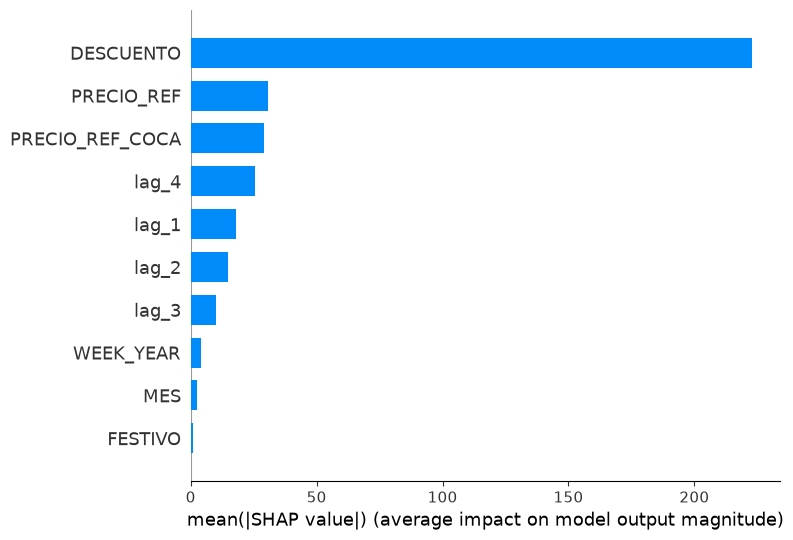

None


In [25]:
X_shap, y_shap = forecaster.create_train_X_y(
    y= y_full,
    exog= exog_full
)

print(X_shap.shape)
print(X_shap.columns.tolist())

# Construimos explainer
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_shap)

# graficamos resultado
print(shap.summary_plot(shap_values, X_shap, plot_type='bar'))




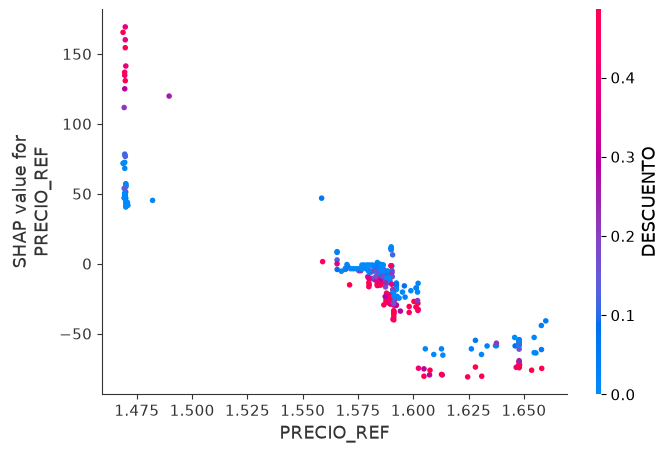

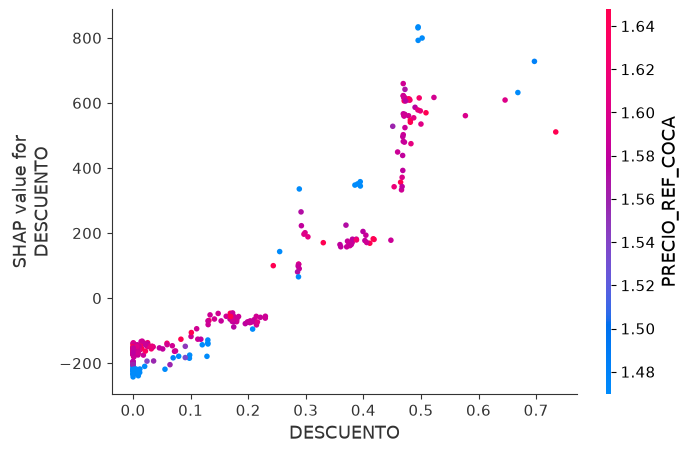

In [26]:
# Respuesta al precio y dto
shap.dependence_plot('PRECIO_REF', shap_values, X_shap)
shap.dependence_plot('DESCUENTO', shap_values, X_shap)

**Importancia global.** El descuento domina con diferencia el resto de variables. El precio de referencia y el precio de Coca-Cola aparecen en un segundo nivel, y todos los lags de demanda quedan por debajo, incluso del precio rival. Un modelo que podía apoyarse en su propio pasado apenas lo hace: es el ACF plano de la fase de descomposición convertido en importancia. Para predecir la demanda semana a semana, la profundidad promocional es el factor decisivo.

El descuento *es* precio, la caída del precio real respecto al regular. Que `PRECIO_REF` tenga importancia baja no significa que la demanda sea insensible a él, sino que el precio regular apenas varía en estos datos: es un percentil 90 en ventana móvil, diseñado para ser estable. La importancia SHAP es, en esencia, **efecto × variación**, y una variable con un efecto grande pero sin apenas recorrido no puede explicar varianza de la predicción. Por eso la elasticidad de −4,62 estimada en el notebook 03 y el SHAP bajo de `PRECIO_REF` son perfectamente compatibles: la demanda sí está gobernada por el precio, pero la acción del precio llega por la vía del descuento.

Esto es coherente con la especificación del notebook 03, que ya separaba `PRECIO_REF` y `DESCUENTO` como dos dimensiones independientes. Lo que SHAP añade no es descubrir el descuento, sino confirmar que, de esas dos dimensiones, la promocional concentra casi todo el peso predictivo, en línea con el coeficiente de descuento de +4,05 obtenido allí.

**Respuesta al precio (dependence plot de `PRECIO_REF`).** La relación es claramente decreciente: a mayor precio regular, menor aportación a la demanda, lo que confirma el signo de la elasticidad de forma no paramétrica. El gráfico está en niveles (€ frente a unidades), no en log-log, por lo que la pendiente no debe leerse como el −4,62 del notebook 03: coincide en dirección, no en magnitud.

**Respuesta al descuento (dependence plot de `DESCUENTO`).** La relación es monótona creciente y de magnitud muy superior a la del precio regular. El color revela además una interacción relevante: los descuentos que más disparan la demanda tienden a coincidir con un precio de Coca-Cola alto. Es decir, la promoción de Pepsi es más efectiva cuando el rival está caro.

## Anexo

En este anexo se van a crear dos escenarios de predicción futuros a un mes vista. Son casos sencillos que se explotaran en mayor medida más adelante.

In [27]:
# Recuperamos última fecha conocida y generamos siguientes fechas
ult_fecha = test_sk.index.max()
fechas_futuras = pd.date_range(start=ult_fecha + pd.Timedelta(weeks=1), periods=4, freq='7D')

futuro = pd.DataFrame(index=fechas_futuras)

futuro['WEEK_YEAR'] = futuro.index.isocalendar().week.astype(int)
futuro['MES'] = futuro.index.month
futuro['FESTIVO'] = 0 # asumimos que no hay festivos en el siguiente mes
futuro['PRECIO_REF_COCA'] = 1.59 # Mantenemos precio cocacola en nivel habitual

In [28]:
# Escenario A: precio regular sin descuento
escenario_a = futuro.copy()
escenario_a['PRECIO_REF'] = 1.59
escenario_a['DESCUENTO'] = 0 

# Escenario B: mismo precio regular pero con descuento
escenario_b = futuro.copy()
escenario_b['PRECIO_REF'] = 1.59
escenario_b['DESCUENTO'] = 0.20

# Ordenamos columnas
escenario_a = escenario_a[exogenas]
escenario_b = escenario_b[exogenas]

In [29]:
# Entrenamiento y predicción 
fc_final.fit(y= y_full, exog= exog_full, store_in_sample_residuals=True)

prediccion_a = fc_final.predict(steps=4, exog=escenario_a)
prediccion_b = fc_final.predict(steps=4, exog=escenario_b)

print("Escenario A (sin descuento):")
print(prediccion_a.round(0))
print("\nEscenario B (20% descuento):")
print(prediccion_b.round(0))

Escenario A (sin descuento):
1997-05-08    117.0
1997-05-15     97.0
1997-05-22    106.0
1997-05-29     99.0
Freq: 7D, Name: pred, dtype: float64

Escenario B (20% descuento):
1997-05-08    201.0
1997-05-15    197.0
1997-05-22    193.0
1997-05-29    190.0
Freq: 7D, Name: pred, dtype: float64


In [30]:
fc_final.set_out_sample_residuals(
    y_true=test_sk.loc[predicciones_lgbm_final.index, 'UNIDADES'],
    y_pred=predicciones_lgbm_final['pred']
)

pred_int_a = fc_final.predict_interval(
    steps=4, exog=escenario_a, interval=[10, 90],
    n_boot=1000, use_in_sample_residuals=False
)

pred_int_a

c:\GitHUB\Portafolio-Data-Science-Python\Pricing-Dominicks\.venv\Lib\site-packages\skforecast\utils\utils.py:1082: FutureWarning: Passing `interval` as percentiles (0-100) is deprecated. Use quantiles (0-1) instead. For example, use `interval=[0.05, 0.95]` instead of `interval=[5, 95]`. Percentile support will be removed in skforecast 0.25.0.
  warnings.warn(


,pred,lower_bound,upper_bound
1997-05-08,116.583125,64.397319,72.513356
1997-05-15,96.826177,63.734286,98.086945
1997-05-22,105.640728,62.920820,716.271349
1997-05-29,98.612599,60.732213,706.661500
